In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

## create the connection with database

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [20]:
test_group = pd.read_sql(
    '''
SELECT uid, AVG((strftime('%s', test.first_commit_ts) - deadlines.deadlines) / 3600) as avg_diff
FROM test
JOIN deadlines ON test.labname = deadlines.labs
WHERE labname <> 'project1'
GROUP BY uid
ORDER BY uid
''', conn
)
test_group

,uid,avg_diff
0,user_1,-64.400000
1,user_10,-74.800000
2,user_14,-159.000000
3,user_17,-61.600000
4,user_18,-5.666667
5,user_19,-98.750000
6,user_21,-95.500000
7,user_25,-92.600000
8,user_28,-86.400000
9,user_3,-105.400000


In [22]:
number_of_pageviews = pd.read_sql(
    '''
SELECT uid, count(datetime) as pageviews
FROM pageviews
WHERE uid LIKE 'user_%'
GROUP BY uid
ORDER BY uid
''', conn
)
number_of_pageviews

,uid,pageviews
0,user_1,28
1,user_10,89
2,user_14,143
3,user_17,47
4,user_18,3
5,user_19,16
6,user_21,10
7,user_25,179
8,user_28,149
9,user_3,317


In [30]:
num_commits = pd.read_sql(
    '''
SELECT uid, COUNT(timestamp) as num_commits
FROM checker
WHERE uid LIKE 'user_%' AND labname <> 'project1'
GROUP BY uid
ORDER BY uid
''', conn
)
num_commits

,uid,num_commits
0,user_0,3
1,user_1,62
2,user_10,20
3,user_11,7
4,user_12,86
5,user_13,52
6,user_14,61
7,user_15,23
8,user_16,41
9,user_17,51


## combining tables

In [32]:
final_table = test_group.merge(number_of_pageviews, on='uid').merge(num_commits, on='uid')
final_table

,uid,avg_diff,pageviews,num_commits
0,user_1,-64.400000,28,62
1,user_10,-74.800000,89,20
2,user_14,-159.000000,143,61
3,user_17,-61.600000,47,51
4,user_18,-5.666667,3,5
5,user_19,-98.750000,16,118
6,user_21,-95.500000,10,65
7,user_25,-92.600000,179,79
8,user_28,-86.400000,149,60
9,user_3,-105.400000,317,18


## make a scatter matrix

array([[<Axes: xlabel='avg_diff', ylabel='avg_diff'>,
        <Axes: xlabel='pageviews', ylabel='avg_diff'>,
        <Axes: xlabel='num_commits', ylabel='avg_diff'>],
       [<Axes: xlabel='avg_diff', ylabel='pageviews'>,
        <Axes: xlabel='pageviews', ylabel='pageviews'>,
        <Axes: xlabel='num_commits', ylabel='pageviews'>],
       [<Axes: xlabel='avg_diff', ylabel='num_commits'>,
        <Axes: xlabel='pageviews', ylabel='num_commits'>,
        <Axes: xlabel='num_commits', ylabel='num_commits'>]], dtype=object)

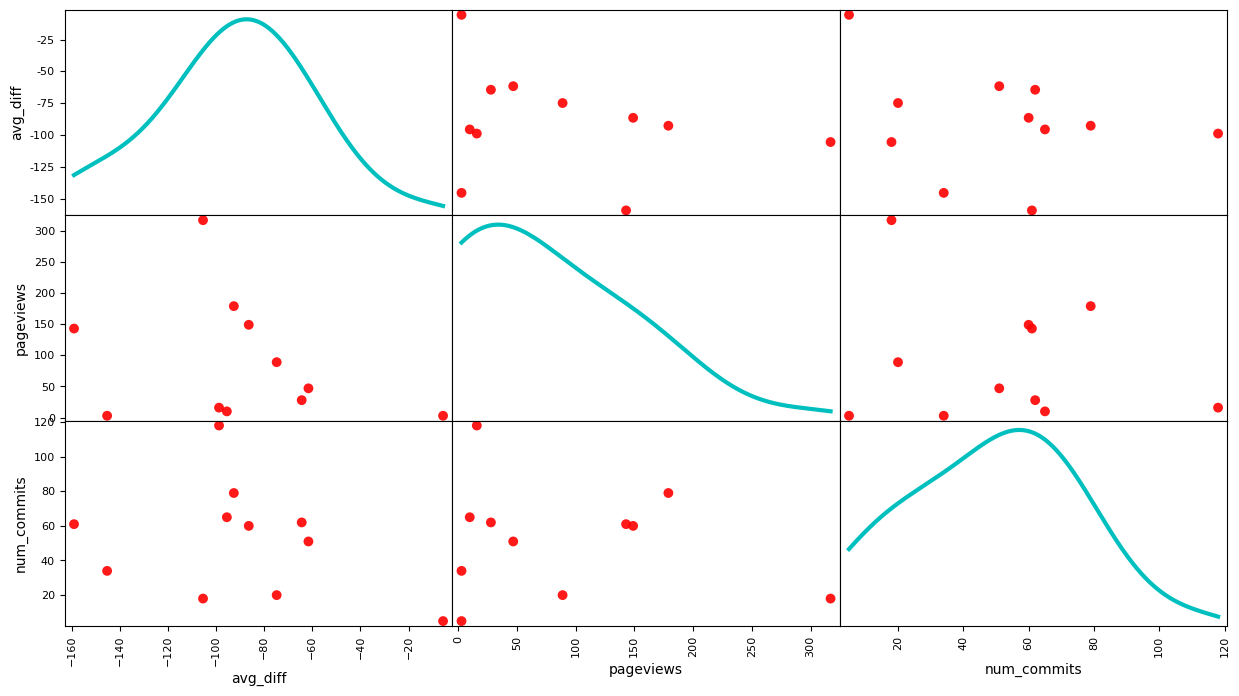

In [41]:
scatter_matrix(final_table,
               figsize=(15,8),
               diagonal='kde',
               s=200,
               color='red',
               alpha=0.9,
               density_kwds=dict(linewidth=3, color='c'))

In [42]:
conn.close()

## Can we say that if a user has a low number of pageviews then they likely have a low number of commits ?
## Ansewer: NO

## Can we say that if a user has a low number of pageviews then they likely have a small average difference between the first commit and the lab deadline?
## Answer: NO

## Can we say that there are many users with a low number of commits and a few with a high number of commits
## Answer: YES

## Can we say that there are many users with a small average difference and a few with a large average difference ?
## Answer: NO